<a href="https://colab.research.google.com/github/atikhasan007/Computer-Vision/blob/main/Optical_Character_Recongition_OCR_PaddleOCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q paddlepaddle==3.2.2
!pip install -q paddleocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/97

In [2]:
image_path = "/content/ilovespain.jpg"

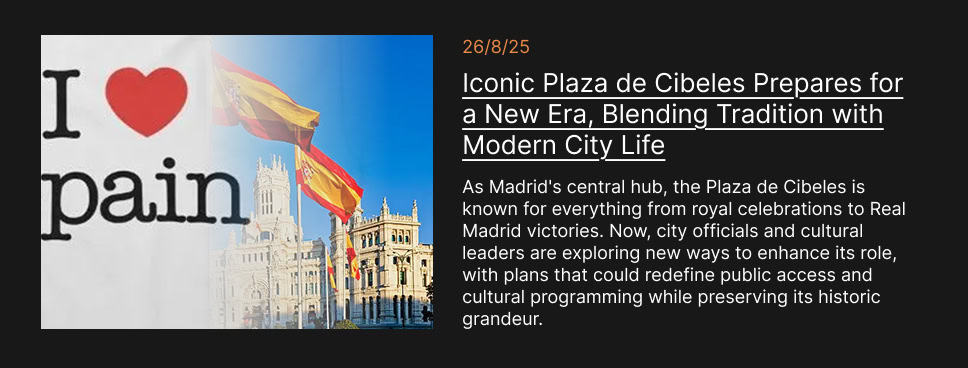

In [9]:
from IPython.display import Image, display
display(Image(filename=image_path))

In [3]:
from paddleocr import PaddleOCR

In [4]:
ocr = PaddleOCR(
    lang="en",
    device="cpu",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False
)

Creating model: ('PP-OCRv6_medium_det', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-OCRv6_medium_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv6_medium_rec', None, None)
Using official model (PP-OCRv6_medium_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

In [5]:
results = ocr.predict(image_path)

In [6]:
results

[{'input_path': '/content/ilovespain.jpg',
  'page_index': None,
  'doc_preprocessor_res': {'output_img': array([[[24, ..., 24],
           ...,
           [24, ..., 24]],
   
          ...,
   
          [[24, ..., 24],
           ...,
           [24, ..., 24]]], dtype=uint8)},
  'dt_polys': [array([[457,  34],
          ...,
          [457,  58]], dtype=int16),
   array([[ 39,  64],
          ...,
          [ 39, 143]], dtype=int16),
   array([[460,  70],
          ...,
          [460,  96]], dtype=int16),
   array([[460, 101],
          ...,
          [460, 126]], dtype=int16),
   array([[460, 131],
          ...,
          [460, 158]], dtype=int16),
   array([[ 32, 145],
          ...,
          [ 32, 249]], dtype=int16),
   array([[460, 176],
          ...,
          [460, 196]], dtype=int16),
   array([[459, 198],
          ...,
          [459, 218]], dtype=int16),
   array([[459, 219],
          ...,
          [459, 240]], dtype=int16),
   array([[460, 243],
          ...,
     

In [7]:
all_text = []

for result in results:
    data = result.json

    # Some PaddleOCR versions wrap the result inside "res"
    if "res" in data:
        data = data["res"]

    texts = data.get("rec_texts", [])
    scores = data.get("rec_scores", [])

    for text, score in zip(texts, scores):
        print(f"{text} | Confidence: {float(score):.2f}")
        all_text.append(text)

extracted_text = "\n".join(all_text)

print("\nComplete extracted text:\n")
print(extracted_text)

26/8/25 | Confidence: 1.00
T | Confidence: 0.32
Iconic Plaza de Cibeles Prepares for | Confidence: 1.00
a New Era, Blending Tradition with | Confidence: 1.00
Modern City Life | Confidence: 1.00
pain | Confidence: 1.00
As Madrid's central hub, the Plaza de Cibeles is | Confidence: 1.00
known for everything from royal celebrations to Real | Confidence: 1.00
Madrid victories. Now, city officials and cultural | Confidence: 1.00
leaders are exploring new ways to enhance its role, | Confidence: 1.00
with plans that could redefine public access and | Confidence: 1.00
cultural programming while preserving its historic | Confidence: 0.99
grandeur. | Confidence: 1.00

Complete extracted text:

26/8/25
T
Iconic Plaza de Cibeles Prepares for
a New Era, Blending Tradition with
Modern City Life
pain
As Madrid's central hub, the Plaza de Cibeles is
known for everything from royal celebrations to Real
Madrid victories. Now, city officials and cultural
leaders are exploring new ways to enhance its role